In [ ]:
import pandas as pd
import re

def parse_scope_file(filepath):
    pdb_to_sccs = {}
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 6:
                continue
            
            sccs_pattern = r'^[a-z]\.\d+\.\d+\.\d+$'
            if re.match(sccs_pattern, parts[2]):
                sccs = parts[2]
                pdb_code = parts[4]
                chain_info = parts[5]
                
                if ':' in chain_info:
                    chain = chain_info.split(':')[0]
                    pdb_id = pdb_code.lower() + chain
                    
                    # If not yet assigned, or current is 'l' class and new is not
                    if pdb_id not in pdb_to_sccs:
                        pdb_to_sccs[pdb_id] = sccs
                    elif pdb_to_sccs[pdb_id].startswith('l.') and not sccs.startswith('l.'):
                        pdb_to_sccs[pdb_id] = sccs
    
    return pdb_to_sccs

pdb_to_sccs = parse_scope_file('/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/dir.des.scope.2.08-stable.txt')


In [116]:
pdb_to_sccs['1oq1A']

'b.29.1.17'

In [ ]:
def add_sccs_columns(df, scope_filepath, protein1_col='Protein1', protein2_col='Protein2'):
    """
    Add SCOPe sccs columns to dataframe.
    
    Args:
        df: DataFrame with protein columns
        scope_filepath: Path to SCOPe .txt file
        protein1_col: Name of first protein column
        protein2_col: Name of second protein column
    
    Returns:
        DataFrame with added Protein1_sccs and Protein2_sccs columns
    """
    # Parse the SCOPe file
    pdb_to_sccs = parse_scope_file(scope_filepath)
    

    # Create a copy to avoid modifying original
    df = df.copy()
    
    # Map proteins to sccs
    df['Protein1_sccs'] = df[protein1_col].map(pdb_to_sccs)
    df['Protein2_sccs'] = df[protein2_col].map(pdb_to_sccs)
    
    return df

In [107]:
pdb_to_sccs

NameError: name 'pdb_to_sccs' is not defined

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [ ]:
93408   px      b.29.1.17       d1oq1a1 1oq1 A:1-220
93409   px      b.29.1.17       d1oq1b_ 1oq1 B:
93410   px      b.29.1.17       d1oq1c1 1oq1 C:1-220
93411   px      b.29.1.17       d1oq1d1 1oq1 D:1-220
282005  px      l.1.1.1 d1oq1a2 1oq1 A:-2-0
282006  px      l.1.1.1 d1oq1c2 1oq1 C:0-0
282007  px      l.1.1.1 d1oq1d2 1oq1 D:-2-0

In [30]:
scope_fp = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/dir.des.scope.2.08-stable.txt'

In [31]:
## Load CPDB pairs and the recalculate TM scores using min
import numpy as np
import pandas as pd

fp = '/home/ubuntu/CIRPIN/cpdb_comparison/foldseek_CPDB_comparison/cpdb_pdbs_2/cpdb_tm_scores_progres_cirpin_scores.csv'

df = pd.read_csv(fp, sep=',')

In [32]:
df

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243
...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035


In [33]:
df_with_sccs = add_sccs_columns(df,scope_fp)

In [72]:
df_with_sccs.tail(40)

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
4129,2d5rB,2iycA,0.35229,0.34518,0.22268,0.21794,0.616785,0.673267,l.1.1.1,d.3.1.7
4130,2dirA,1ao3A,0.39256,0.49525,0.24868,0.30672,0.477437,0.593369,l.1.1.1,c.62.1.1
4131,2dttA,2gjvA,0.36299,0.36299,0.30417,0.30417,0.572621,0.701172,d.96.1.0,l.1.1.1
4132,2dttA,1askA,0.30986,0.38987,0.27939,0.34792,0.454530,0.528955,d.96.1.0,d.17.4.2
4133,2dttA,1ar0A,0.31813,0.39021,0.28763,0.34897,0.453140,0.529715,d.96.1.0,d.17.4.2
4134,2f40A,2u1aA,0.57616,0.57616,0.51571,0.51571,0.964814,0.914642,l.1.1.1,d.58.7.1
4135,2fhmA,1f9hA,0.55421,0.66620,0.37158,0.42124,0.655235,0.716724,d.58.10.0,d.58.30.1
4136,2fhmA,1hq2A,0.55234,0.67333,0.37104,0.42381,0.659297,0.719649,d.58.10.0,d.58.30.1
4137,2fhmA,1dy3A,0.55125,0.66668,0.36968,0.42062,0.662546,0.716639,d.58.10.0,d.58.30.1
4138,2gjfA,1uv7A,0.51809,0.58508,0.50890,0.57500,0.401839,0.943357,NaN,d.67.4.1


In [73]:
df_with_sccs = df_with_sccs.rename(columns={
    'tmscore': 'tmscore_max',
    'tmscore-CP': 'tmscore_cp_max',
    'tm_score_calculated': 'tmscore_min',
    'tm_score_cp_calculated': 'tmscore_cp_min'
})

df_with_sccs['tm_score_min_difference'] = df_with_sccs['tmscore_cp_min'] - df_with_sccs['tmscore_min']

In [74]:
df_with_sccs

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference
0,1fp3A,1vd5A,0.67760,0.67760,0.67760,0.67760,0.939401,0.983705,a.102.1.3,a.102.1.7,0.00000
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068
...,...,...,...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320,d.108.1.4,d.108.1.10,0.09985
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863,d.108.1.4,d.108.1.10,0.10253
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663,d.108.1.4,d.108.1.10,0.10143
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035,d.108.1.4,d.108.1.10,0.10129


In [75]:
df_with_sccs.to_csv('CPDB_full_data_ark.csv', index=False)


In [106]:
df_with_sccs1 = df_with_sccs[df_with_sccs['tmscore_cp_min'] > 0.5]
print(len(df_with_sccs1))
df_with_sccs1delta = df_with_sccs1[(df_with_sccs1['tmscore_cp_min']-df_with_sccs1['tmscore_min']) > 0]
print(len(df_with_sccs1delta))

2535
2259


In [104]:
len(df_with_sccs1delta)

3181

In [41]:
df = df[df['tm_score_cp_calculated'] > 0.5]

df_tm_cps = df[(df['tm_score_cp_calculated']-df['tm_score_calculated']) > 0]

In [44]:
df_tm_cps = add_sccs_columns(df_tm_cps,scope_fp)

In [45]:
df_tm_cps.head()

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1


In [51]:
mask = (
    (df_tm_cps["Protein1_sccs"] == df_tm_cps["Protein2_sccs"]) &
    df_tm_cps["Protein1_sccs"].notna() &
    df_tm_cps["Protein2_sccs"].notna()
)

df_tm_cps_no_same_sccs = df_tm_cps[~mask]

In [68]:
df_tm_cps

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1
...,...,...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320,d.108.1.4,d.108.1.10
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863,d.108.1.4,d.108.1.10
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663,d.108.1.4,d.108.1.10
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035,d.108.1.4,d.108.1.10


In [69]:
df_tm_cps_no_same_sccs.head(20)

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1
6,1nc5A,2drqA,0.65850,0.66306,0.63718,0.64225,0.968383,0.993673,a.102.1.6,a.102.1.2
7,1nc5A,1ghqA,0.58885,0.64552,0.58885,0.64552,0.920800,0.963621,a.102.1.6,l.1.1.1
8,1nc5A,1c3dA,0.57529,0.62801,0.57529,0.62801,0.913858,0.969388,a.102.1.6,l.1.1.1
9,1nc5A,1qqfA,0.53718,0.59195,0.53718,0.59195,0.908040,0.964480,a.102.1.6,a.102.4.4
10,1v5cA,1fo2A,0.65778,0.67728,0.57082,0.58921,0.928022,0.980578,a.102.1.2,a.102.2.1


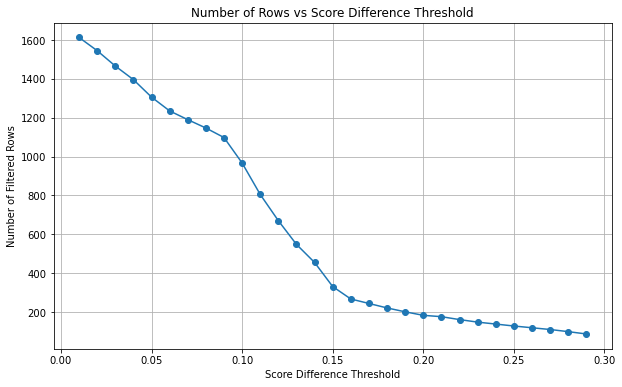

In [53]:
import matplotlib.pyplot as plt
import numpy as np

score_diff_lens = {}
for i in np.arange(0.01, 0.3, 0.01):  # 0.01 to 0.1 in 0.01 increments
    df_diff = df_tm_cps_no_same_sccs[
        (df_tm_cps_no_same_sccs['tm_score_cp_calculated'] - df_tm_cps_no_same_sccs['tm_score_calculated'] > i)
    ]
    score_diff_lens[i] = len(df_diff)

# Plot dictionary
plt.figure(figsize=(10, 6))
plt.plot(list(score_diff_lens.keys()), list(score_diff_lens.values()), marker='o')
plt.xlabel('Score Difference Threshold')
plt.ylabel('Number of Filtered Rows')
plt.title('Number of Rows vs Score Difference Threshold')
plt.grid(True)
plt.show()

In [76]:
df_tm_cps

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1
...,...,...,...,...,...,...,...,...,...,...
4164,1xe4A,2hv2A,0.47581,0.59132,0.43224,0.53209,0.832416,0.969320,d.108.1.4,d.108.1.10
4165,1xe4A,2i00A,0.45702,0.58056,0.40431,0.50684,0.860363,0.974863,d.108.1.4,d.108.1.10
4166,1xf8A,2hv2A,0.47354,0.59084,0.43024,0.53167,0.835343,0.965663,d.108.1.4,d.108.1.10
4167,1xf8A,2i00A,0.45886,0.58051,0.40551,0.50680,0.860762,0.971035,d.108.1.4,d.108.1.10


In [82]:
import pandas as pd

fp_cpdb_full = 'CPDB_full_data_ark.csv'
cpdb_full = pd.read_csv(fp_cpdb_full)

In [84]:
cpdb_full = cpdb_full[
    (cpdb_full['tmscore_cp_min'] > 0.5) &
    ((cpdb_full['tmscore_cp_min'] - cpdb_full['tmscore_min']) > 0)
]

In [95]:
cpdb_full[cpdb_full['Protein1'] == '1fp3A']

,Protein1,Protein2,tmscore_max,tmscore_cp_max,tmscore_min,tmscore_cp_min,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs,tm_score_min_difference
1,1fp3A,1wu4A,0.67768,0.67887,0.67768,0.67887,0.971649,0.990784,a.102.1.3,a.102.1.2,0.00119
2,1fp3A,2drqA,0.67558,0.67691,0.67558,0.67691,0.976586,0.990878,a.102.1.3,a.102.1.2,0.00133
3,1fp3A,1wu6A,0.67434,0.67558,0.67434,0.67558,0.974675,0.990933,a.102.1.3,a.102.1.2,0.00124
4,1fp3A,1hzfA,0.54695,0.55763,0.54695,0.55763,0.911674,0.948243,a.102.1.3,a.102.4.4,0.01068
5,1fp3A,1ks8A,0.63233,0.69125,0.59385,0.64707,0.958750,0.982420,a.102.1.3,l.1.1.1,0.05322


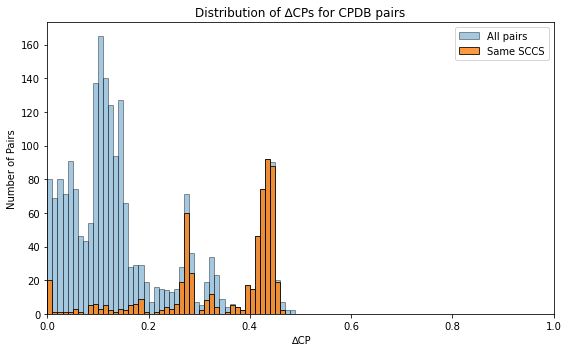

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# compute ΔCP once
diff = cpdb_full['tmscore_cp_min'] - cpdb_full['tmscore_min']

# mask for same SCCS
same_sccs = cpdb_full['Protein1_sccs'] == cpdb_full['Protein2_sccs']

# shared bins so bars align
bins = np.linspace(0, 1, 101)

plt.figure(figsize=(8, 5))

# background: all pairs
plt.hist(
    diff,
    bins=bins,
    edgecolor="black",
    alpha=0.4,
    label="All pairs"
)

# highlighted: same SCCS
plt.hist(
    diff[same_sccs],
    bins=bins,
    edgecolor="black",
    alpha=0.8,
    label="Same SCCS"
)

plt.xlim(0, 1)
plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")
plt.legend()
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


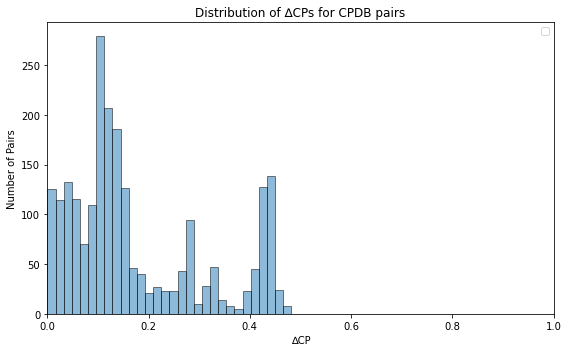

In [90]:
plt.figure(figsize=(8, 5))
plt.hist((cpdb_full['tmscore_cp_min'] - cpdb_full['tmscore_min']), 
         bins=30, edgecolor="black", alpha=0.5)
plt.xlim(0, 1)
plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")
plt.legend()
plt.tight_layout()
plt.savefig('CPDB_tm_diff_dist.pdf')
plt.show()

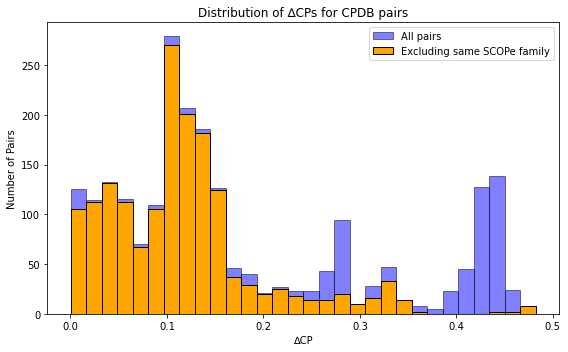

In [67]:
plt.figure(figsize=(8, 5))
plt.hist((df_tm_cps['tm_score_cp_calculated'] - df_tm_cps['tm_score_calculated']), 
         bins=30, edgecolor="black", alpha=0.5, label='All pairs', color='blue')
plt.hist((df_tm_cps_no_same_sccs['tm_score_cp_calculated'] - df_tm_cps_no_same_sccs['tm_score_calculated']), 
         bins=30, edgecolor="black", alpha=1, label='Excluding same SCOPe family', color='orange')
plt.xlabel("∆CP")
plt.ylabel("Number of Pairs")
plt.title("Distribution of ∆CPs for CPDB pairs")
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
df_same_sccs = df_tm_cps[
    df_tm_cps["Protein1_sccs"].notna() &
    df_tm_cps["Protein2_sccs"].notna() &
    (df_tm_cps["Protein1_sccs"] == df_tm_cps["Protein2_sccs"])
]

In [47]:
len(df_tm_cps)

2259

In [48]:
len(df_same_sccs)

586

In [49]:
df_same_sccs

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
537,1l3pA,1nlxA,0.62705,0.67800,0.61776,0.66790,0.990689,0.989440,a.24.17.1,a.24.17.1
820,1jf0A,1prwA,0.45598,0.52366,0.45598,0.52366,0.973755,0.979054,a.39.1.5,a.39.1.5
825,1nyaA,1prwA,0.41997,0.58432,0.41997,0.58432,0.967175,0.979064,a.39.1.5,a.39.1.5
828,1prwA,2sasA,0.55797,0.68087,0.47243,0.57017,0.963018,0.974341,a.39.1.5,a.39.1.5
830,1qv0A,1dtlA,0.53604,0.58661,0.53604,0.58661,0.959814,0.970897,a.39.1.5,a.39.1.5
...,...,...,...,...,...,...,...,...,...,...
4154,1ti1A,1un2A,0.48785,0.93896,0.48785,0.93896,0.991267,0.995208,c.47.1.13,c.47.1.13
4155,1un2A,1bq7A,0.51353,0.96431,0.51353,0.96431,0.989165,0.995577,c.47.1.13,c.47.1.13
4156,1un2A,2b3sA,0.47834,0.91446,0.47593,0.90986,0.985751,0.993427,c.47.1.13,c.47.1.13
4159,1yzxA,1un2A,0.30365,0.56550,0.30365,0.56550,0.976762,0.971317,c.47.1.13,c.47.1.13


In [50]:
{
    "p1_na": df_tm_cps["Protein1_sccs"].isna().sum(),
    "p2_na": df_tm_cps["Protein2_sccs"].isna().sum(),
    "either_na": (df_tm_cps["Protein1_sccs"].isna() | df_tm_cps["Protein2_sccs"].isna()).sum(),
    "both_na": (df_tm_cps["Protein1_sccs"].isna() & df_tm_cps["Protein2_sccs"].isna()).sum(),
}


{'p1_na': 74, 'p2_na': 71, 'either_na': 135, 'both_na': 10}

In [40]:
df_with_sccs[df_with_sccs["Protein1_sccs"].isna()]

,Protein1,Protein2,tmscore,tmscore-CP,tm_score_calculated,tm_score_cp_calculated,progres_score,cirpin_score,Protein1_sccs,Protein2_sccs
721,1zzpA,1p68A,0.47875,0.63391,0.47875,0.63391,0.908784,0.976683,NaN,k.8.1.1
737,2clbA,1cd9A,0.55043,0.66147,0.53348,0.64172,0.512788,0.967083,NaN,a.26.1.1
738,2clbA,1b71A,0.69150,0.69150,0.60724,0.60724,0.904089,0.912053,NaN,g.41.5.1
739,2clbA,1i1rB,0.46292,0.60774,0.45854,0.60194,0.603825,0.965855,NaN,a.26.1.1
740,2clbA,1lkiA,0.50947,0.63061,0.49176,0.60922,0.553474,0.942457,NaN,a.26.1.1
...,...,...,...,...,...,...,...,...,...,...
4103,1ygtA,2dttA,0.40773,0.57367,0.40470,0.56950,0.605424,0.938685,NaN,d.96.1.0
4119,2aj0A,2nptB,0.35060,0.32219,0.32134,0.29971,0.430362,0.580944,NaN,d.15.2.2
4138,2gjfA,1uv7A,0.51809,0.58508,0.50890,0.57500,0.401839,0.943357,NaN,d.67.4.1
4139,2gjfA,2bjdA,0.55104,0.55104,0.48493,0.48493,0.730695,0.701564,NaN,d.58.10.0
